This dataset shows the annual visits of materials at Toronto Public Library branches.

**Visits** is defined as a combination of:
- first-time checkouts (i.e. when items are initially borrowed) and
- renewals (i.e. transactions that extend the due dates of borrowed items). 

This data covers the **visits of physical materials** (e.g. books, CDs, DVDs, etc.) and electronic resources (e.g. ebooks, streaming content, etc.).

The branch associated with a visits total is the library from which the transactions were processed.

For **online renewals** of physical materials, the visits is associated with the home branch of the renewing customer.

The VIR (Virtual Library) branch code is used to represent all electronic visits totals.

# 0. imports

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
cwd = os.environ["REPO_ROOT"]
print(cwd)
os.chdir(cwd)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from utils.download_data import download_data
import math
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_columns', None)

/home/ruchirich/Documents/repositories/toronto-open-data/tpl


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        1233 non-null   object
 1   BranchCode  1233 non-null   object
 2   Visits      1233 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 29.0+ KB
None
   Year BranchCode  Visits
0  2012         AB  522309
1  2012        ACD  214076
2  2012         AD   88065
3  2012         AG  434320
4  2012         AH   67184


<Axes: xlabel='Year'>

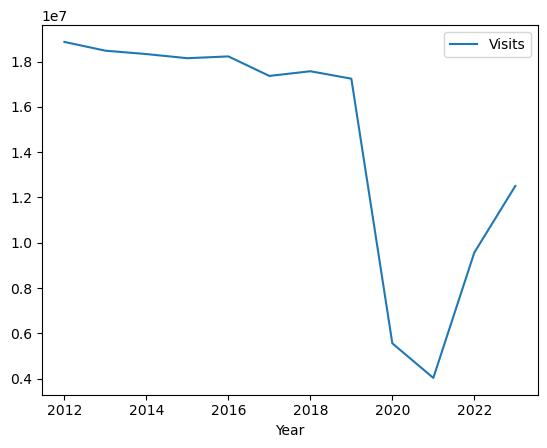

In [65]:
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "library-visits"}
visits_file = cwd+"/data/library-visits.csv"

download_data(params, visits_file)
usecols = ['Year', 'BranchCode', 'Visits']
visits = pd.read_csv(visits_file, usecols=usecols, parse_dates=["Year"], date_format="%Y")
visits['Year'] = visits["Year"].dt.year.astype("object")
print(visits.info())
print(visits.head())

# Plot annual visits at TPL
visits[['Year', 'Visits']].groupby('Year').sum().plot.line()

In [66]:
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "library-branch-general-information"}
branch_info_file = cwd+"/data/library-branch-general-information.csv"

download_data(params, branch_info_file)
# usecols = ["BranchCode", "BranchName", "PhysicalBranch"]
# branch_info = pd.read_csv(branch_info_file, usecols=usecols)
branch_info = pd.read_csv(branch_info_file)
print(branch_info.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _id                   112 non-null    int64  
 1   BranchCode            112 non-null    object 
 2   PhysicalBranch        112 non-null    int64  
 3   BranchName            112 non-null    object 
 4   Address               103 non-null    object 
 5   PostalCode            103 non-null    object 
 6   Website               108 non-null    object 
 7   Telephone             105 non-null    object 
 8   SquareFootage         110 non-null    object 
 9   PublicParking         100 non-null    object 
 10  KidsStop              100 non-null    float64
 11  LeadingReading        100 non-null    float64
 12  CLC                   100 non-null    float64
 13  DIH                   100 non-null    float64
 14  TeenCouncil           100 non-null    float64
 15  YouthHub              1

## 0.1. data

In [67]:
# visits_branch_info = pd.concat(objs=, axis=1, join="outer")
visits_branch_info = visits.merge(right=branch_info, indicator=True, left_on="BranchCode", right_on="BranchCode", how="left",validate="m:1")
print(visits_branch_info.head())

   Year BranchCode  Visits  _id  PhysicalBranch       BranchName  \
0  2012         AB  522309    1               1           Albion   
1  2012        ACD  214076    2               1  Albert Campbell   
2  2012         AD   88065    3               1        Alderwood   
3  2012         AG  434320    4               1        Agincourt   
4  2012         AH   67184    5               1   Armour Heights   

                                     Address PostalCode  \
0     1515 Albion Road, Toronto, ON, M9V 1B2    M9V 1B2   
1  496 Birchmount Road, Toronto, ON, M1K 1N8    M1K 1N8   
2      2 Orianna Drive, Toronto, ON, M8W 4Y1    M8W 4Y1   
3     155 Bonis Avenue, Toronto, ON, M1T 3W6    M1T 3W6   
4     2140 Avenue Road, Toronto, ON, M5M 4M7    M5M 4M7   

                             Website     Telephone SquareFootage  \
0          https://www.tpl.ca/albion  416-394-5170         29000   
1  https://www.tpl.ca/albertcampbell  416-396-8890         28957   
2       https://www.tpl.ca/alder

In [68]:
data = pd.read_csv("data/data_binary_classification.csv")

data["Visits"] = visits_branch_info["Visits"]
data = data.drop(columns="_id")

data.to_csv(path_or_buf="data/data_binary_classification.csv", index=False)

# 1. PhysicalBranch (Online vs. Physical)

In [69]:
visits_by_physical_branch = visits_branch_info[["Year", "PhysicalBranch", "Visits"]].pivot_table(index="Year", columns="PhysicalBranch", values="Visits", aggfunc="sum")
visits_by_physical_branch

PhysicalBranch,0,1
Year,,
2012,78217,18794396
2013,64813,18420581
2014,55726,18280205
2015,47376,18105701
2016,60065,18172302
2017,66161,17303871
2018,63120,17514253
2019,54903,17193858
2020,17714,5540037


In [70]:
visits_by_physical_branch_melted = visits_by_physical_branch.reset_index().melt(id_vars="Year", var_name="PhysicalBranch", value_name="Visits")

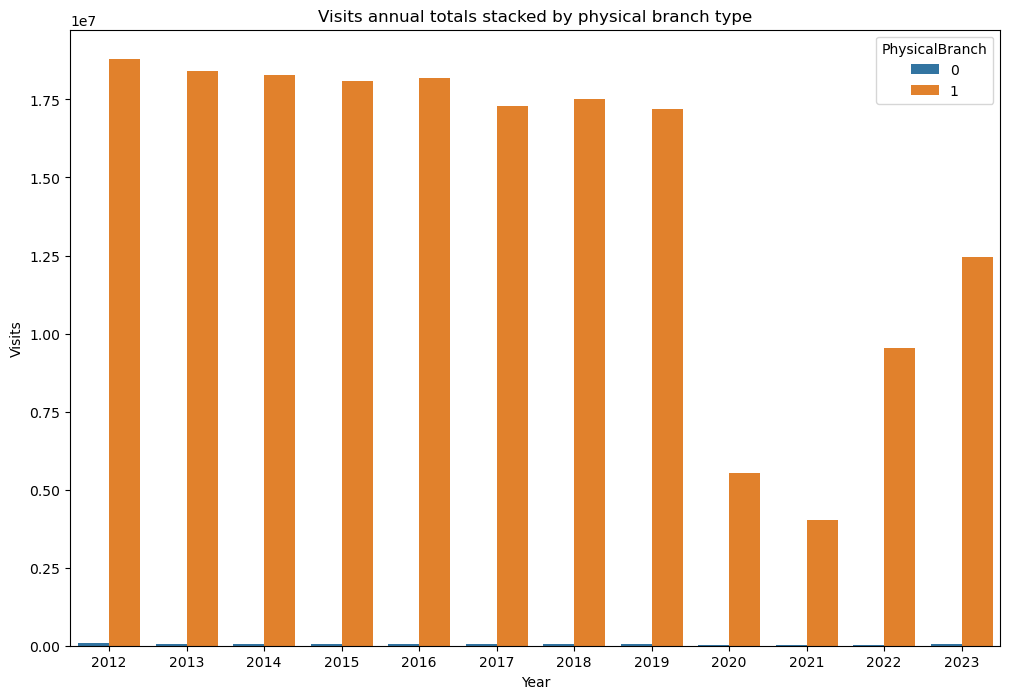

In [71]:
fig = plt.figure(1, figsize=(12, 8))
ax = fig.add_subplot(111)

plot = sns.barplot(
    data=visits_by_physical_branch_melted,
    x="Year",
    y="Visits",
    hue="PhysicalBranch",
    dodge=True,
    ax=ax,
    palette="tab10",
    errorbar=None
)

ax.set(
    title="Visits annual totals stacked by physical branch type",
    xlabel="Year",
    ylabel="Visits",
)
# ax.xaxis.set_ticklabels([])
# ax.yaxis.set_ticklabels([])

# for container in ax.containers:
#     ax.bar_label(container=container, labels=)


plt.show()
fig.savefig(fname="output/annual_visits_by_physical_branch_indicator.png")

In [72]:
visits_by_physical_branch_pct = visits_by_physical_branch.copy(deep=True)
visits_by_physical_branch_pct[0] = visits_by_physical_branch_pct[0] / (visits_by_physical_branch_pct[0] + visits_by_physical_branch_pct[1]) * 100
visits_by_physical_branch_pct[1] = visits_by_physical_branch_pct[1] / (visits_by_physical_branch[0] + visits_by_physical_branch_pct[1]) * 100
print(visits_by_physical_branch_pct)

PhysicalBranch         0          1
Year                               
2012            0.414447  99.585553
2013            0.350617  99.649383
2014            0.303917  99.696083
2015            0.260981  99.739019
2016            0.329442  99.670558
2017            0.380892  99.619108
2018            0.359098  99.640902
2019            0.318301  99.681699
2020            0.318726  99.681274
2021            0.304902  99.695098
2022            0.406137  99.593863
2023            0.319952  99.680048


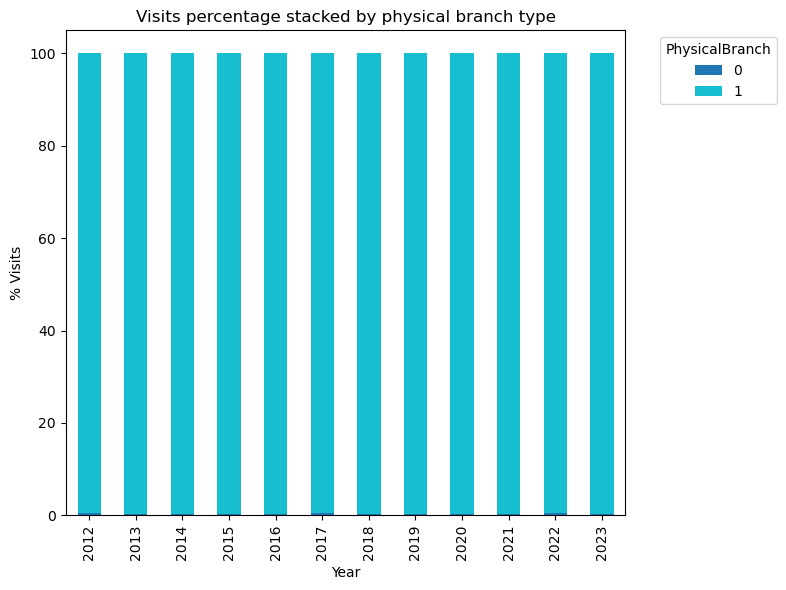

In [73]:
# Create stacked bar chart
fig, ax = plt.subplots(figsize=(8, 6))
visits_by_physical_branch_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')

ax.set(
    title="Visits percentage stacked by physical branch type",
    xlabel="Year",
    ylabel="% Visits",
)
ax.legend(title='PhysicalBranch', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
fig.savefig(fname="output/annual_percentage_visits_by_physical_branch_indicator.png")

## Log Scale Plot

In [74]:
visits_by_physical_branch = visits_branch_info[["Year", "PhysicalBranch", "Visits"]].pivot_table(index="Year", columns="PhysicalBranch", values="Visits", aggfunc="sum")
print(visits_by_physical_branch)
visits_by_physical_branch[0] = np.log10(visits_by_physical_branch[0])
visits_by_physical_branch[1] = np.log10(visits_by_physical_branch[1])
print(visits_by_physical_branch)
visits_by_physical_branch_melted = visits_by_physical_branch.reset_index().melt(id_vars="Year", var_name="PhysicalBranch", value_name="Visits")

PhysicalBranch      0         1
Year                           
2012            78217  18794396
2013            64813  18420581
2014            55726  18280205
2015            47376  18105701
2016            60065  18172302
2017            66161  17303871
2018            63120  17514253
2019            54903  17193858
2020            17714   5540037
2021            12286   4017202
2022            38853   9527633
2023            40019  12467804
PhysicalBranch         0         1
Year                              
2012            4.893301  7.274028
2013            4.811662  7.265303
2014            4.746058  7.261981
2015            4.675558  7.257815
2016            4.778621  7.259410
2017            4.820602  7.238143
2018            4.800167  7.243392
2019            4.739596  7.235373
2020            4.248317  6.743513
2021            4.089411  6.603924
2022            4.589425  6.978985
2023            4.602266  7.095790


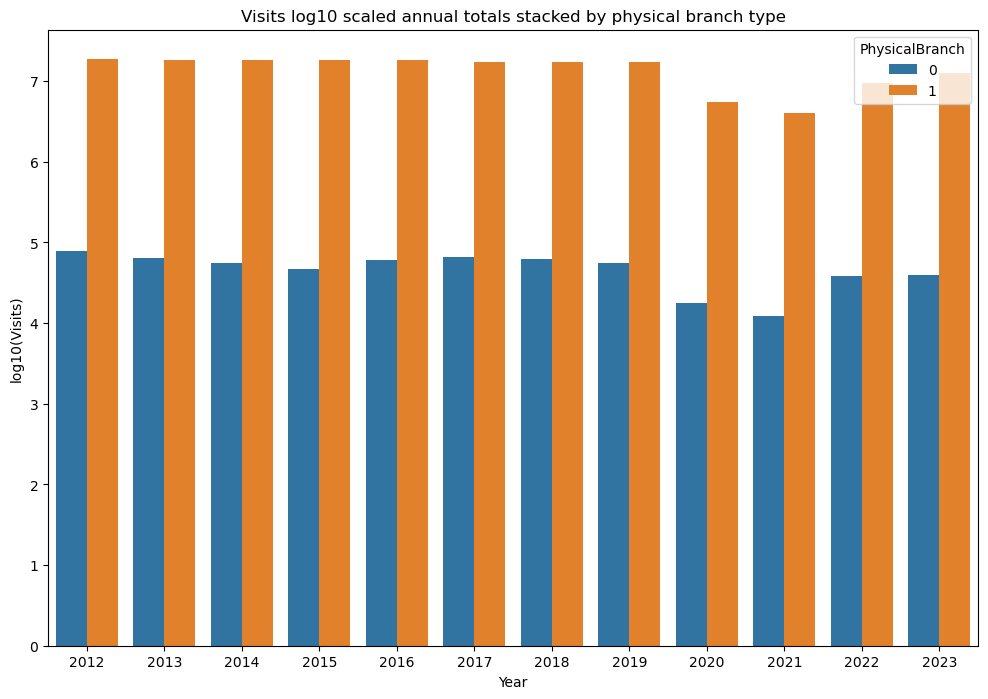

In [75]:
fig = plt.figure(1, figsize=(12, 8))
ax = fig.add_subplot(111)

plot = sns.barplot(
    data=visits_by_physical_branch_melted,
    x="Year",
    y="Visits",
    hue="PhysicalBranch",
    dodge=True,
    ax=ax,
    palette="tab10",
    errorbar=None
)

ax.set(
    title="Visits log10 scaled annual totals stacked by physical branch type",
    xlabel="Year",
    ylabel="log10(Visits)",
)
# ax.xaxis.set_ticklabels([])
# ax.yaxis.set_ticklabels([])

# for container in ax.containers:
#     ax.bar_label(container=container, labels=)


plt.show()
fig.savefig(fname="output/log_annual_visits_by_physical_branch_indicator.png")


## 1.0 Online Branch drilldown

In [76]:
online_visits = visits_branch_info[visits_branch_info['PhysicalBranch'] == 0]
print(online_visits.head())

     Year BranchCode  Visits  _id  PhysicalBranch           BranchName  \
12   2012      BKONE   39749   14               0       Bookmobile One   
59   2012         ME    7612   68               0    Merril Collection   
67   2012         OS    9372   76               0   Osborne Collection   
82   2012         SB   21484   92               0  Sunnybrook Hospital   
113  2013      BKONE   31488   14               0       Bookmobile One   

                                               Address PostalCode  \
12                                                 NaN        NaN   
59   239 College Street, 3rd floor, Toronto, ON, M5...    M5T 1R5   
67   239 College Street, 4th floor, Toronto, ON, M5...    M5T 1R5   
82   2075 Bayview Avenue, Aging and Veterans Care, ...    M4N 3M5   
113                                                NaN        NaN   

                                 Website                Telephone  \
12        https://www.tpl.ca/bookmobiles                      NaN   
59

In [77]:
branch_stats = online_visits.groupby(by='BranchCode').Visits.describe()
branch_stats.sort_values(by='max', ascending=False)

,count,mean,std,min,25%,50%,75%,max
BranchCode,,,,,,,,
BKONE,12.0,16748.500000,10796.849225,2798.0,9512.75,14775.0,20128.25,39749.0
SB,12.0,13555.666667,7237.825092,787.0,6549.25,15916.5,18804.75,21484.0
OS,12.0,11233.833333,4894.755149,4813.0,6642.25,10894.0,15742.00,19171.0
ME,12.0,8399.750000,3953.029405,1.0,7458.50,8543.0,10360.25,14550.0


## 1.1 Library Collections branches

Osborne and Merill Collections at Lilian H.Smith branch

In [78]:
branch_info[branch_info['BranchCode'] == 'OS']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
75,76,OS,0,Osborne Collection,"239 College Street, 4th floor, Toronto, ON, M5...",M5T 1R5,https://www.tpl.ca/osborne,416-393-7753,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RR,43.65785,-79.39864,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
branch_info[branch_info['BranchCode'] == 'ME']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
67,68,ME,0,Merril Collection,"239 College Street, 3rd floor, Toronto, ON, M5...",M5T 1R5,https://www.tpl.ca/merril,416-393-7748,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RR,43.657222,-79.398333,NaN,NaN,NaN,NaN,NaN,NaN


## 1.3 Sunnybrook

The service provided supports the Sunnybrook community - its hospital patients, veterans and staff.

In [80]:
branch_info[branch_info['BranchCode'] == 'SB']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
91,92,SB,0,Sunnybrook Hospital,"2075 Bayview Avenue, Aging and Veterans Care, ...",M4N 3M5,https://www.tpl.ca/hospital-service,416-480-6100 EXT 62624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Year', ylabel='Visits'>

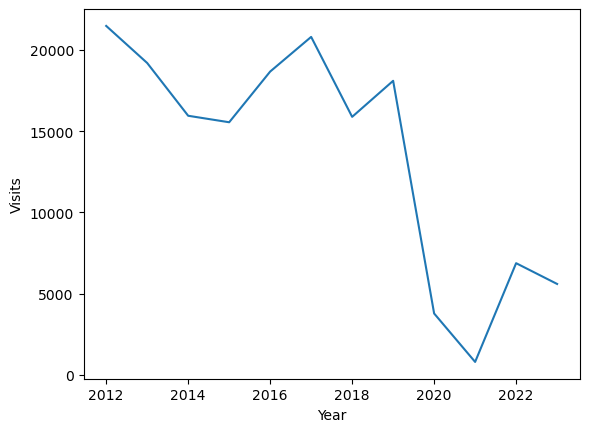

In [81]:
Sunnybrook = online_visits[online_visits['BranchCode'] == 'SB']

sns.lineplot(data=Sunnybrook, x='Year', y='Visits')

# APPENDIX

## A.1 Correlation plot

Correlation of `Visits` in `BranchCode` feature

In [82]:
visits_by_branch = visits.pivot(columns='BranchCode',index='Year',values='Visits')
visits_by_branch = visits_by_branch.dropna()
visits_correlation = visits_by_branch.corr()

<Figure size 800x600 with 0 Axes>

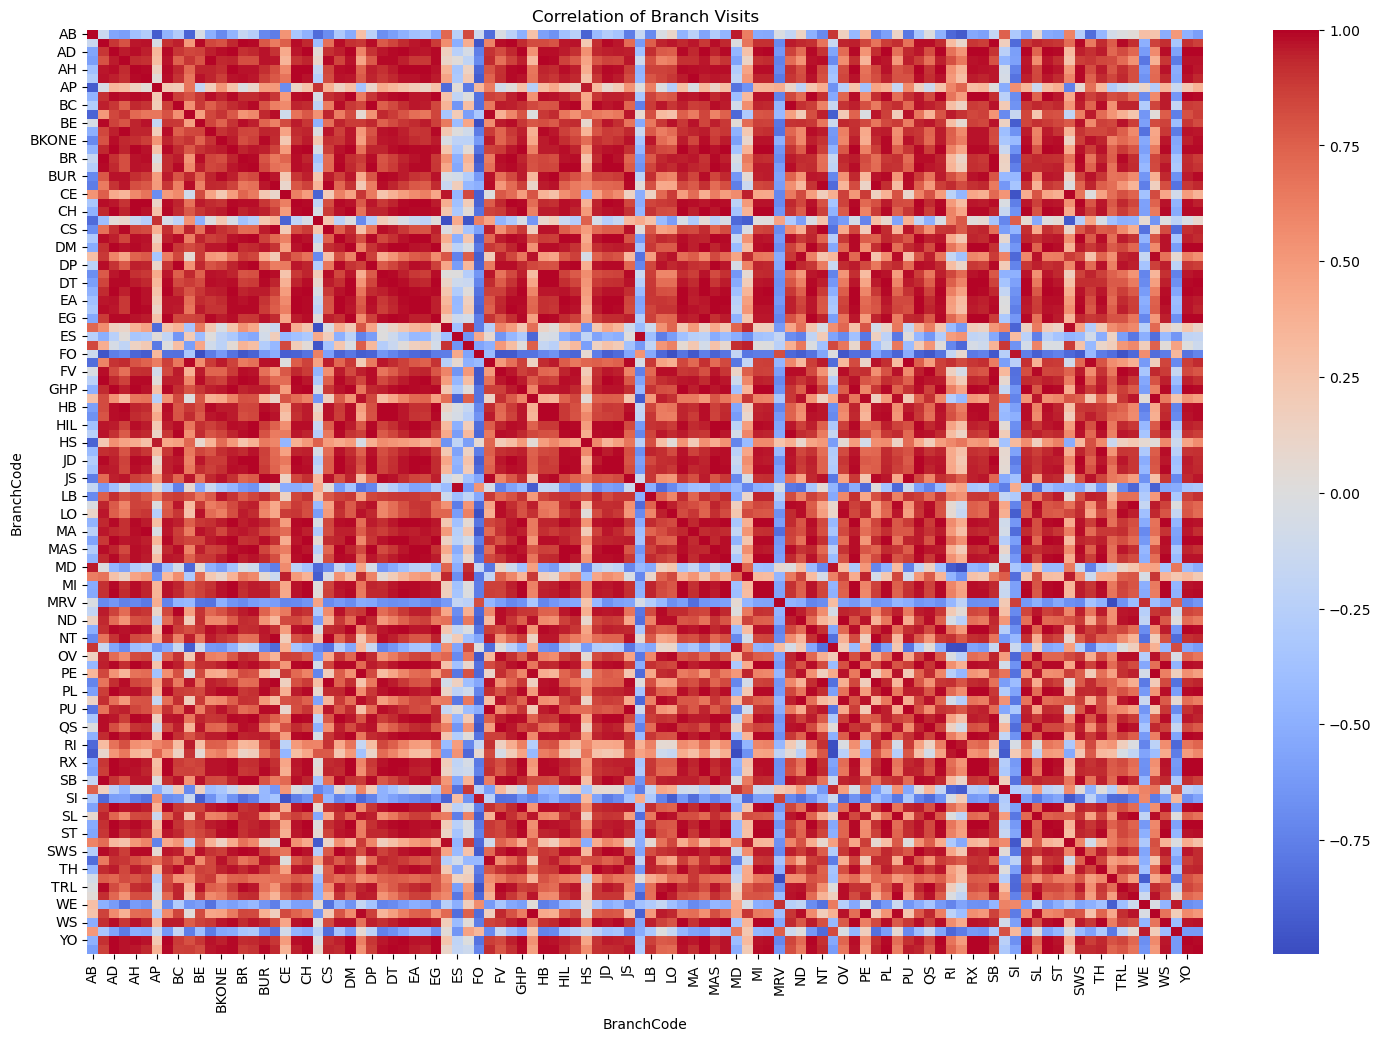

In [83]:
fig = plt.figure(1, figsize=(8, 6))
# ax = fig.add_subplot(111)

plt.figure(figsize=(18,12))
heatmap = sns.heatmap(data=visits_correlation,cmap='coolwarm')

heatmap.set(
    title="Correlation of Branch Visits",
    xlabel="BranchCode",
    ylabel="BranchCode",
)
# heatmap.xaxis.set_ticklabels([])
# heatmap.yaxis.set_ticklabels([])

# plt.show()
fig.savefig(fname="output/Branch_Visits_Correlation.png")

## A.2 PCA

Single Valued Decomposition of `BranchCode` feature across `Year` dimensions

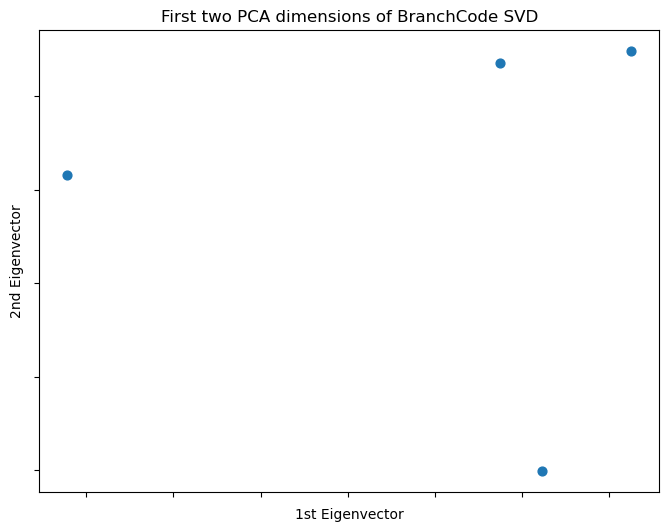

In [84]:
from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111)
X_reduced = PCA(n_components=2).fit_transform(visits_by_branch)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    s=40,
)

ax.set(
    title="First two PCA dimensions of BranchCode SVD",
    xlabel="1st Eigenvector",
    ylabel="2nd Eigenvector",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

plt.show()
fig.savefig(fname="output/PCA_Visits_2D.png")

In [85]:
X_reduced

array([[ 449815.09918937,  297566.06975075],
       [ 148367.17034546,  271609.06771274],
       [-842730.82381844,   32150.54354952],
       [ 244548.55428361, -601325.68101301]])

In [86]:
X_reduced.shape

(4, 2)